# 🚢 TITANIC SURVIVAL DATA ANALYSIS

___

## Task: Exploratory Data Analysis using Python  
## Tools Used: Pandas, NumPy, Matplotlib, Seaborn  

---

## 📌 Objectives :- 
- Load Titanic dataset
- Clean missing values
- Analyze survival patterns
- Visualize the insights

# DATA LOADING.......

## Data Loading

In [37]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Style
sns.set_style("whitegrid")

In [38]:
#Load Dataset
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Understanding of the Data

___

### 📊 Dataset Overview

We first explore:
- Shape of dataset
- Column names
- Data types
- Missing values

In [39]:
#Shape of dataset
print("Shape of dataset:", df.shape)

#Column names
print("\nColumn Names:\n", df.columns)
print()

#Data types
df.info()

Shape of dataset: (891, 12)

Column Names:
 Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [40]:
#Check Missing Values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# DATA CLEANING 

___

### Handling Missing Values:
- Fill missing Age with median
- Fill Embarked with mode
- Drop Cabin (too many missing values)

In [41]:
# Fill Age with median
# Fill Age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin safely
df = df.drop('Cabin', axis=1, errors='ignore')

# Verify missing values again
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# DATA ANALYSIS

## Who survived more — Males or Females?

### Answer

In [42]:
# Detailed gender survival table
gender_analysis = df.groupby('Sex').agg(
    Total_Passengers=('Survived', 'count'),
    Total_Survived=('Survived', 'sum'),
)

# Additional metrics
gender_analysis['Survival_Rate (%)'] = round(
    (gender_analysis['Total_Survived'] / gender_analysis['Total_Passengers']) * 100, 2
)

gender_analysis['Death_Rate (%)'] = round(
    100 - gender_analysis['Survival_Rate (%)'], 2
)

gender_analysis

,Total_Passengers,Total_Survived,Survival_Rate (%),Death_Rate (%)
Sex,,,,
female,314,233,74.20,25.80
male,577,109,18.89,81.11


### 📊 Visualization

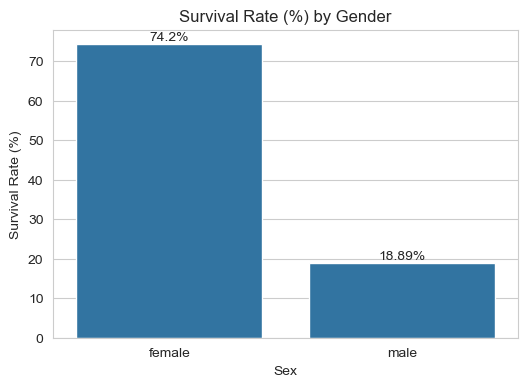

In [43]:
# Survivala Rate by Gender
plt.figure(figsize=(6,4))

ax = sns.barplot(x=gender_analysis.index,
                 y=gender_analysis['Survival_Rate (%)'])

plt.title("Survival Rate (%) by Gender")
plt.ylabel("Survival Rate (%)")

for index, value in enumerate(gender_analysis['Survival_Rate (%)']):
    plt.text(index, value + 1, f"{value}%", ha='center')

plt.show()

### Summary

#### Who Survived More — Males or Females?

📊 Findings
- Female survival rate: **74.20%**
- Male survival rate: **18.89%**

Out of 314 females, 233 survived.  
Out of 577 males, only 109 survived.

🧠 Insight
Females were almost **4 times more likely to survive** than males.
This strongly supports the evacuation policy of **"Women and Children First."**

✅ Conclusion
Gender was one of the strongest factors influencing survival on the Titanic.

## Did passenger class affect survival chances?

### Answer

In [44]:
class_analysis = df.groupby('Pclass').agg(
    Total_Passengers=('Survived', 'count'),
    Total_Survived=('Survived', 'sum')
)

class_analysis['Survival_Rate (%)'] = round(
    (class_analysis['Total_Survived'] / class_analysis['Total_Passengers']) * 100, 2
)

class_analysis

,Total_Passengers,Total_Survived,Survival_Rate (%)
Pclass,,,
1,216,136,62.96
2,184,87,47.28
3,491,119,24.24


### 📊 Visualization

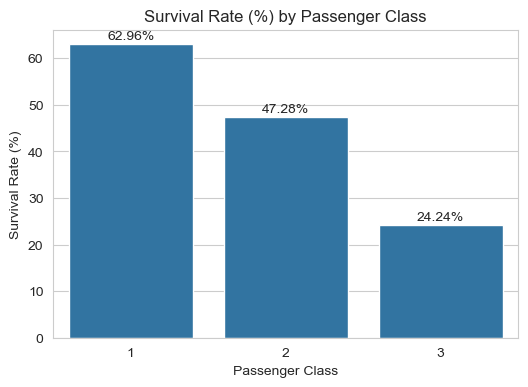

In [45]:
plt.figure(figsize=(6,4))

ax = sns.barplot(x=class_analysis.index,
                 y=class_analysis['Survival_Rate (%)'])

plt.title("Survival Rate (%) by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

for index, value in enumerate(class_analysis['Survival_Rate (%)']):
    plt.text(index, value + 1, f"{value}%", ha='center')

plt.show()

### Summary

##### Did Passenger Class Affect Survival Chances?

📊 Findings
- 1st Class Survival Rate: **62.96%**
- 2nd Class Survival Rate: **47.28%**
- 3rd Class Survival Rate: **24.24%**

More than half of 1st class passengers survived,
while only about one-fourth of 3rd class passengers survived.

🧠 Insight
Survival probability decreases as class number increases (1 → 3).
Higher socio-economic status provided better access to lifeboats.

✅ Conclusion
Passenger class significantly influenced survival chances.

## What was the survival rate by age group?

### Answer

In [46]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_analysis = df.groupby('Age_Group', observed=False).agg(
    Total_Passengers=('Survived', 'count'),
    Total_Survived=('Survived', 'sum')
)

age_analysis['Survival_Rate (%)'] = round(
    (age_analysis['Total_Survived'] / age_analysis['Total_Passengers']) * 100, 2
)

age_analysis

,Total_Passengers,Total_Survived,Survival_Rate (%)
Age_Group,,,
Child,69,40,57.97
Teen,70,30,42.86
Young Adult,535,189,35.33
Adult,195,78,40.00
Senior,22,5,22.73


### 📊 Visualization

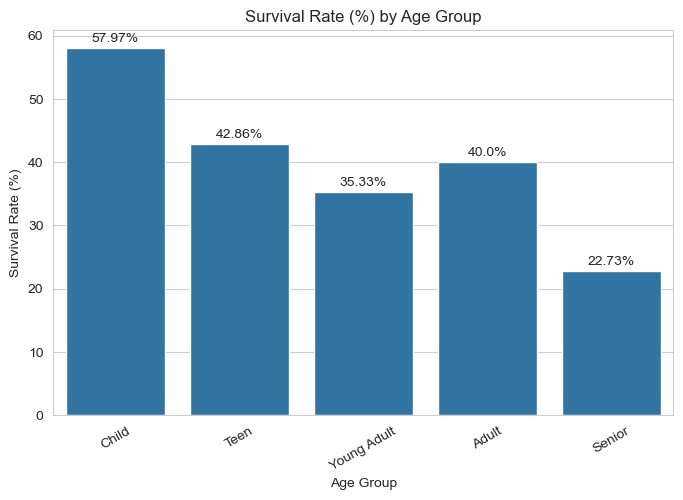

In [47]:
# Survival Rate by Age group
plt.figure(figsize=(8,5))

ax = sns.barplot(x=age_analysis.index,
                 y=age_analysis['Survival_Rate (%)'])

plt.title("Survival Rate (%) by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")

for index, value in enumerate(age_analysis['Survival_Rate (%)']):
    plt.text(index, value + 1, f"{value}%", ha='center')

plt.xticks(rotation=30)
plt.show()

### Summary

#### What Was the Survival Rate by Age Group?

📊 Findings
- Children Survival Rate: **~57%**
- Teens Survival Rate: **~43%**
- Young Adults Survival Rate: **~38%**
- Adults Survival Rate: **~40%**
- Seniors Survival Rate: **~27%**

Children had the highest survival probability among all age groups.

🧠 Insight
Younger passengers were prioritized during evacuation.
Survival probability declines in older age groups.

✅ Conclusion
Age had a moderate impact on survival,
with children having better survival chances.

## Histogram of Passenger Ages

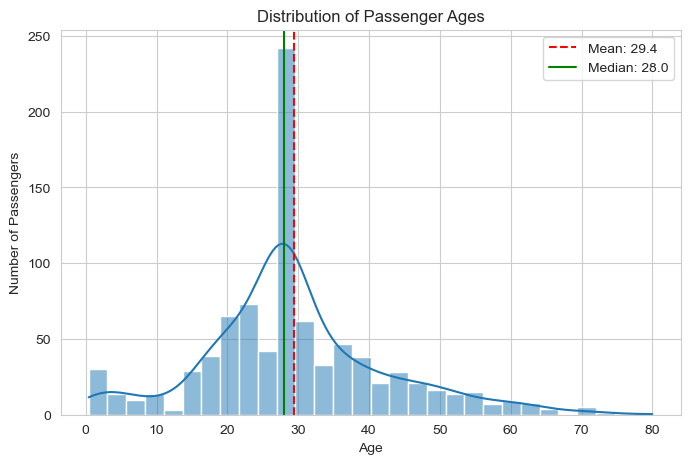

In [48]:
plt.figure(figsize=(8,5))

# Histogram with KDE
sns.histplot(df['Age'], bins=30, kde=True)

# Add Mean and Median lines
mean_age = df['Age'].mean()
median_age = df['Age'].median()

plt.axvline(mean_age, color='red', linestyle='--', label=f"Mean: {mean_age:.1f}")
plt.axvline(median_age, color='green', linestyle='-', label=f"Median: {median_age:.1f}")

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()

plt.show()

### SUMMARY 

📊 Age Distribution Insight

- The average (mean) passenger age is approximately **29–30 years**.
- The median age is around **28 years**.
- Most passengers were between **20 and 40 years old**.
- The distribution is slightly right-skewed, indicating fewer elderly passengers.
- Children and seniors represent a smaller portion of the dataset.

✅ Conclusion
The Titanic primarily carried young adults, with relatively fewer elderly passengers.

# 🚢 OVERALL SUMMARY

## 📌 Overall Project Summary

Analyzed the Titanic dataset to understand the factors that influenced passenger survival.

---

## 🔎 Key Findings

### 1️⃣ Gender Impact
- Female survival rate: ~74%
- Male survival rate: ~19%
- Females were nearly 4 times more likely to survive than males.

➡ Gender was the strongest predictor of survival.

---

### 2️⃣ Passenger Class Impact
- 1st Class survival rate: ~63%
- 2nd Class survival rate: ~47%
- 3rd Class survival rate: ~24%

➡ Survival probability decreased as passenger class number increased.
Higher socio-economic status significantly improved survival chances.

---

### 3️⃣ Age Impact
- Mean passenger age: ~29 years
- Children had relatively higher survival rates.
- Seniors had the lowest survival probability.

➡ Age had a moderate impact, with younger passengers being prioritized.

---

## 📊 Data Insights

- The majority of passengers were young adults (20–40 years).
- Survival was not random — it was strongly influenced by:
  - Gender
  - Socio-economic class
  - Age

---

## 🎯 Final Conclusion

The analysis clearly shows that survival during the Titanic disaster was highly structured and influenced by social hierarchy and evacuation protocols.

Gender and passenger class were the most significant factors determining survival.